In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

#CDMS = os.environ["CDMS"] # set in .bash_profile
#stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
#plt.style.use(stylesheet)

#sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
#import setup

/usr/local/lib/python3.10/dist-packages/CDMSDataCatalog/CDMSDataCatalog.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Welcome to JupyROOT 6.28/10


In [2]:
from scipy.optimize import curve_fit
from uncertainties import ufloat
import math

def func(x, a, b):
    return a*x + b

def fit_logPulse(x, y, start, stop):
    popt, pcov = curve_fit(func, x[start:stop], y[start:stop])
    return popt[0], np.sqrt(np.diag(pcov))[0], popt[1], np.sqrt(np.diag(pcov))[1]

def str_with_err(value, error):
    digits = -int(math.floor(math.log10(error)))
    return "{0:.{2}f}({1:.0f})".format(value, error*10**digits, digits)

### Retrieve T3Z1 PTOFamps and EventTime data

In [3]:
ProdTag = 'CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6'

In [4]:
# Z1 0V R37
series_list=['23240104_051944', '23231222_074513', 
'23231221_235414', '23231221_223301', 
'23231221_162803']
# Z1 0V R38
#series_list=['23240310_103543', '23240310_045613',
#'23240310_015547', '23240305_084620', 
#'23240305_050626', '23240305_030542', 
#'23240221_012437']

In [7]:
filepath = [f'/scratch/perry/CDMS/CUTE/R37/Processed/Releases/{ProdTag}/Submerged/{ProdTag}_{i}.root' for i in series_list]

In [8]:
det = 1 # detector number
df = CDataFrame("rqDir/zip"+str(det), filepath, friends = [[x+":rqDir/eventTree" for x in filepath]])

In [9]:
## Apply some basic data quality filters and get the RQs you're interested in
logfile = '"cute_tower3testing.log"'
df = df.Define("LEDLogFile", logfile) 
df = df.CDefine("LEDOn", supercuts.ledOn_old, ["EventTime", "LEDLogFile"])
df = df.Filter("!LEDOn")
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(det), "PTOFamps>0"])

In [10]:
RQs = (["SeriesNumber", "PTOFamps", "EventNumber", "EventTime"])
df_rqs = df_filtered.AsNumpy(RQs)

### Define material properties and reference dates

In [11]:
import datetime
from zoneinfo import ZoneInfo

dt = datetime.datetime.now(ZoneInfo("America/New_York"))
print(dt)

2025-09-29 14:25:04.615134-04:00


In [12]:
# Cf252 radioactive properties
Cf252_halflife = 8.341e7 # s
Cf252_lifetime = Cf252_halflife / np.log(2) # s
Cf252_lambda   = 1 / Cf252_lifetime # Hz

# Ge-71 radioactive properties
Ge71_halflife = 990835 # s
Ge71_lifetime = Ge71_halflife / np.log(2) # s
Ge71_lambda   = 1 / Ge71_lifetime

In [13]:
Cf252_activity = 37000                                                # activity of Cf252 at reference time; given in Hz
t_ref          = datetime.datetime(2020, 3, 15, 00, 0, tzinfo=ZoneInfo("America/New_York")).timestamp()    # reference time of nominal activity; Unix time
activ_prob     = 9208e-9                                              # Ge activations per neutron emitted; found using sourcesim w/ CUTE geometry

# rate of Ge activation during exposure
A = Cf252_activity * activ_prob # activations / second

### Set up for integrating over activation and decay periods, read in and store time stamps of exposure periods

In [14]:
start_times = pd.read_csv('../source_exposure_start_times.csv')
end_times = pd.read_csv('../source_exposure_end_times.csv')

exposures = {i: {} for i in range(8)}

for i in range(8):
    year_0, year_f   = start_times['year'][i], end_times['year'][i]
    month_0, month_f = start_times['month'][i], end_times['month'][i]
    day_0, day_f     = start_times['day'][i], end_times['day'][i]
    hour_0, hour_f   = start_times['hour'][i], end_times['hour'][i]
    min_0, min_f     = start_times['minute'][i], end_times['minute'][i]
    s_0, s_f         = start_times['second'][i], end_times['second'][i]
    exposures[i]['t0'] = datetime.datetime(year_0, month_0, day_0, hour_0, min_0, s_0, tzinfo=ZoneInfo("America/New_York")).timestamp()
    exposures[i]['tf'] = datetime.datetime(year_f, month_f, day_f, hour_f, min_f, s_f, tzinfo=ZoneInfo("America/New_York")).timestamp()
    exposures[i]['dt'] = exposures[i]['tf'] - exposures[i]['t0']

In [15]:
# find total activations with N = int[ A exp( -lambda_Cf252 (t + t0) ) * exp(-lambda_Ge71 (T - t) ) ] dt + N0 exp(-lambda_Ge71 T) 
# t from t0 to T
def integrate_activations(N, T, t0):
    return (A / (Cf252_lambda - Ge71_lambda) * ( np.exp(- Cf252_lambda * t0 - Ge71_lambda * T) - np.exp(-Cf252_lambda * (T + t0)) ) + 
            N * np.exp(-Ge71_lambda * T) )

In [17]:
# data-taking window
datataking_start = datetime.datetime(2023, 12, 21, 0, 0, 0, tzinfo=ZoneInfo("America/New_York")).timestamp()
datataking_end = datetime.datetime(2024, 1, 4, 0, 0, 0, tzinfo=ZoneInfo("America/New_York")).timestamp()

In [18]:
#datataking_start = datetime.datetime(2024, 2, 21, 0, 0, 0, tzinfo=ZoneInfo("America/New_York")).timestamp()
#datataking_end = datetime.datetime(2024, 3, 10, 0, 0, 0, tzinfo=ZoneInfo("America/New_York")).timestamp()

### Plot exposure history (number of Ge-71 nuclei vs. time)

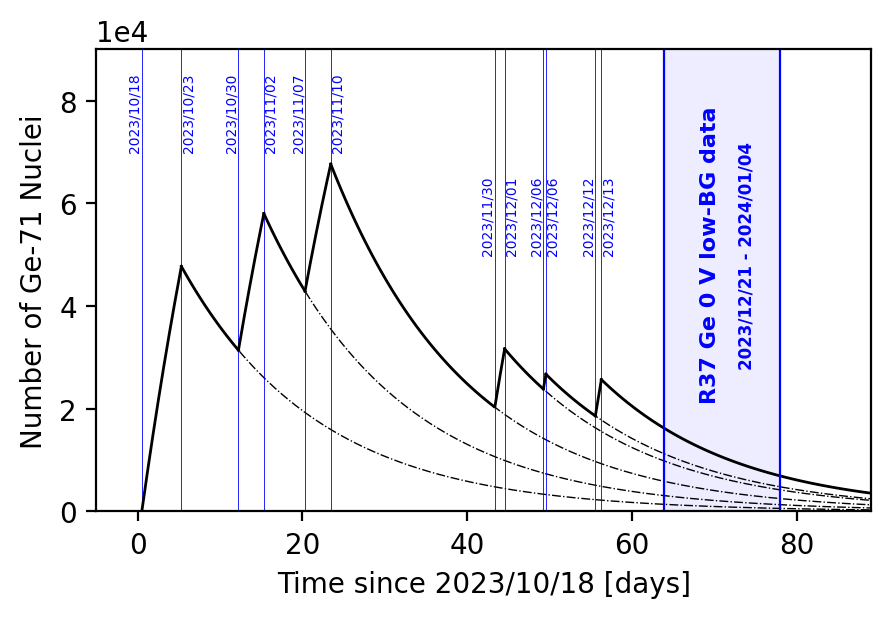

In [20]:
s2day = 1.157e-5
# time window for plotting
window_start = datetime.datetime(2023, 10, 18, 0, 0, 0).timestamp()
window_end = datetime.datetime(2024, 1, 10, 0, 0, 0).timestamp()
#window_end = datetime.datetime(2024, 4, 1, 0, 0, 0).timestamp()

# initial number of activated Ge-71 nuclei
N = 0

plt.figure(figsize=(5,3), dpi=200)

for i in range(len(exposures)):
    # Small exposure windows that clutter the plot. Exclude for plotting.
    if (i == 3) | (i == 4):
        continue
    # range of current exposure period
    t0      = exposures[i]['t0']
    tf      = exposures[i]['tf']
    
    # start of next exposure period (or end of window for plotting)
    t0_next = exposures[i+1]['t0'] if (i != len(exposures)-1) else window_end + 5/s2day
    
    # number of activated nuclei (N_activ) vs. time (t)
    t       = np.arange(t0, tf, 1)
    N_activ = integrate_activations(N, t - t0, t0 - t_ref)

    # vertical line and label at start and end of exposure window
    v_position = 7e4 if (i < 5) else 5e4
    start_text = datetime.datetime.fromtimestamp(t0).strftime("%Y/%m/%d")
    end_text = datetime.datetime.fromtimestamp(tf).strftime("%Y/%m/%d")
    plt.axvline((t0 - window_start)*s2day, 0, 1, lw = 0.3, color = 'blue')
    plt.axvline((tf - window_start)*s2day, 0, 1, lw = 0.3, color = 'blue')
    #plt.axvspan((t0 - window_start)*s2day, (tf - window_start)*s2day, alpha=0.03, color='blue', lw=0)
    plt.text((t0 - window_start)*s2day, v_position, start_text, rotation=90, fontsize = 5, ha='right', va='bottom', color = 'blue')
    plt.text((tf - window_start)*s2day, v_position, end_text, rotation=90, fontsize = 5, ha='left', va='bottom', color = 'blue')

    #### plot activations vs. time at start of window ####
    plt.plot((t - window_start)*s2day, N_activ, color = 'black', lw = 1)

    #### plot the decay of nuclei when not exposed to a source ####
    # need number of nuclei at end of exposure period (N0) and time range until next exposure period (delta_t)
    delta_t = np.linspace(0, t0_next - t[-1], 101)
    N0 = N_activ[-1]
    plt.plot((tf + delta_t - window_start)*s2day, N0 * np.exp(-Ge71_lambda * delta_t), color = 'black', lw = 1)
    # extrapolate to t -> inf
    delta_t_inf = np.linspace(0, t0_next*2 - t[-1], int(1e6))
    plt.plot((tf + delta_t_inf - window_start)*s2day, N0 * np.exp(-Ge71_lambda * delta_t_inf), color = 'black', lw = 0.5, ls = 'dashdot')
    # reset N (number of activated nuclei) for next exposure iteration
    N = N0 * np.exp(-Ge71_lambda * delta_t)[-1]

# indicate window of data-taking
start_text = datetime.datetime.fromtimestamp(datataking_start, tz=ZoneInfo("America/New_York")).strftime("%Y/%m/%d")
end_text = datetime.datetime.fromtimestamp(datataking_end, tz=ZoneInfo("America/New_York")).strftime("%Y/%m/%d")
plt.axvline((datataking_start - window_start)*s2day, 0, 1, lw = 0.8, color = 'blue')
plt.axvline((datataking_end - window_start)*s2day, 0, 1, lw = 0.8, color = 'blue')#
plt.text((datataking_end - window_start)*s2day/2 + (datataking_start - window_start)*s2day/2 - 1.5, 5e4, 
        'R37 Ge 0 V low-BG data', rotation=90, fontsize = 8, ha='center', va='center', color = 'blue', fontweight='bold')
plt.text((datataking_end - window_start)*s2day/2 + (datataking_start - window_start)*s2day/2 + 3, 5e4, 
        start_text + ' - ' + end_text, rotation=90, fontsize = 6, ha='center', va='center', color = 'blue', fontweight='bold')
plt.axvspan((datataking_start - window_start)*s2day, (datataking_end - window_start)*s2day, alpha=0.07, color='blue', lw=0)


plt.ylim(0, 9e4)
plt.xlim(-5, (window_end - window_start) * s2day + 5)
plt.xlabel(f'Time since {datetime.datetime.fromtimestamp(window_start).strftime("%Y/%m/%d")} [days]')
plt.ylabel('Number of Ge-71 Nuclei')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

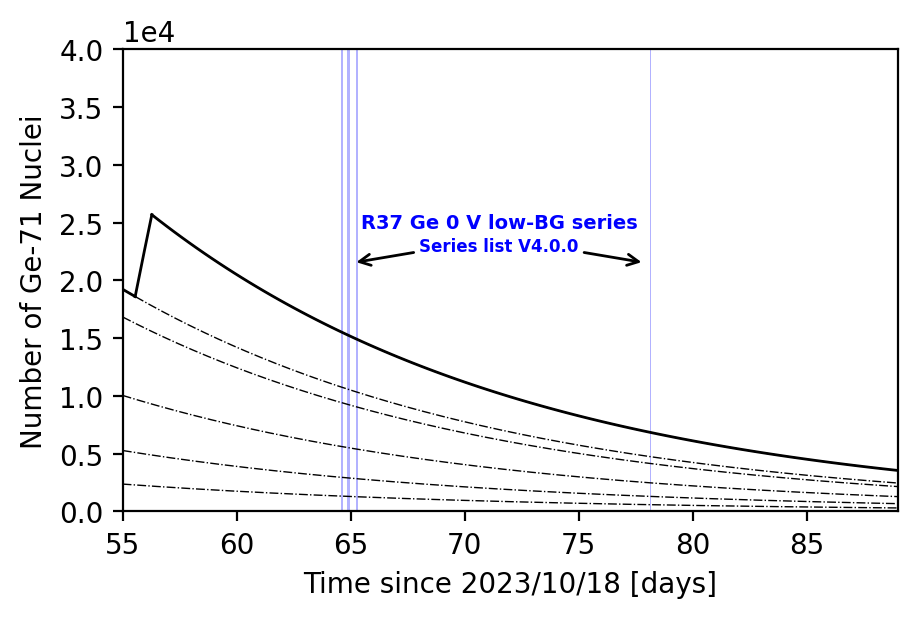

In [25]:
s2day = 1.157e-5
# time window for plotting
window_start = datetime.datetime(2023, 10, 18, 0, 0, 0).timestamp()
window_end = datetime.datetime(2024, 1, 10, 0, 0, 0).timestamp()
#window_end = datetime.datetime(2024, 4, 1, 0, 0, 0).timestamp()

# initial number of activated Ge-71 nuclei
N = 0

plt.figure(figsize=(5,3), dpi=200)

for i in range(len(exposures)):
    # Small exposure windows that clutter the plot. Exclude for plotting.
    if (i == 3) | (i == 4):
        continue
    # range of current exposure period
    t0      = exposures[i]['t0']
    tf      = exposures[i]['tf']
    
    # start of next exposure period (or end of window for plotting)
    t0_next = exposures[i+1]['t0'] if (i != len(exposures)-1) else window_end + 5/s2day
    
    # number of activated nuclei (N_activ) vs. time (t)
    t       = np.arange(t0, tf, 1)
    N_activ = integrate_activations(N, t - t0, t0 - t_ref)

    #### plot activations vs. time at start of window ####
    plt.plot((t - window_start)*s2day, N_activ, color = 'black', lw = 1)

    #### plot the decay of nuclei when not exposed to a source ####
    # need number of nuclei at end of exposure period (N0) and time range until next exposure period (delta_t)
    delta_t = np.linspace(0, t0_next - t[-1], 101)
    N0 = N_activ[-1]
    plt.plot((tf + delta_t - window_start)*s2day, N0 * np.exp(-Ge71_lambda * delta_t), color = 'black', lw = 1)
    # extrapolate to t -> inf
    delta_t_inf = np.linspace(0, t0_next*2 - t[-1], int(1e6))
    plt.plot((tf + delta_t_inf - window_start)*s2day, N0 * np.exp(-Ge71_lambda * delta_t_inf), color = 'black', lw = 0.5, ls = 'dashdot')
    # reset N (number of activated nuclei) for next exposure iteration
    N = N0 * np.exp(-Ge71_lambda * delta_t)[-1]

for sn in np.unique(df_rqs['SeriesNumber']):
    snCut = df_rqs['SeriesNumber'] == sn
    evtTimes = df_rqs['EventTime'][snCut]
    sn_start = min(evtTimes)
    sn_end = max(evtTimes)

    # vertical line and label at start and end of exposure window
    start_text = datetime.datetime.fromtimestamp(sn_start, tz=ZoneInfo("America/New_York")).strftime("%Y/%m/%d")
    end_text = datetime.datetime.fromtimestamp(sn_end, tz=ZoneInfo("America/New_York")).strftime("%Y/%m/%d")
    plt.axvspan((sn_start - window_start)*s2day, (sn_end - window_start)*s2day, alpha=0.3, color='blue', lw=0)

plt.text(71.5, 2.5e4, 'R37 Ge 0 V low-BG series', fontsize = 7, ha='center', va='center', color = 'blue', fontweight='bold')
plt.text(71.5, 2.3e4, 'Series list V4.0.0', fontsize = 6, ha='center', va='center', color = 'blue', fontweight='bold')
plt.annotate("", xytext=(68, 2.3e4-0.05e4), xy=(68-3, 2.3e4-0.1e4-0.05e4),
            arrowprops=dict(arrowstyle="->"), color = 'blue')
plt.annotate("", xytext=(75, 2.3e4-0.05e4), xy=(75+3, 2.3e4-0.1e4-0.05e4),
            arrowprops=dict(arrowstyle="->"), color = 'blue')


plt.ylim(0, 4e4)
plt.xlim(55, (window_end - window_start) * s2day + 5)
plt.xlabel(f'Time since {datetime.datetime.fromtimestamp(window_start).strftime("%Y/%m/%d")} [days]')
plt.ylabel('Number of Ge-71 Nuclei')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

In [22]:
#### starting with 0 nuclei activated ####
N = 0

#### track change in number of Ge-71 nuclei during and after exposures ####
for i in range(len(exposures)):
    N = integrate_activations(N, exposures[i]['dt'], exposures[i]['t0'] - t_ref)
    if (i != len(exposures) - 1):
        N = N * np.exp(-Ge71_lambda * (exposures[i+1]['t0'] - (exposures[i]['t0'] + exposures[i]['dt'])))
    else:
        # check change in number of Ge-71 during each series
        N_tot = 0
        for sn in np.unique(df_rqs['SeriesNumber']):
            snCut = df_rqs['SeriesNumber'] == sn
            evtTimes = df_rqs['EventTime'][snCut]
            sn_start = min(evtTimes)
            sn_end = max(evtTimes)

            N_start = N * np.exp(-Ge71_lambda * (sn_start - (exposures[len(exposures) - 1]['t0'] + exposures[len(exposures) - 1]['dt'])))
            N_end = N * np.exp(-Ge71_lambda * (sn_end - (exposures[len(exposures) - 1]['t0'] + exposures[len(exposures) - 1]['dt'])))
            print(N_start)
            print(N_end)
            print(f'{np.round(N_start - N_end)} Ge-71 events in series {int(sn)}')

            N_tot += N_start - N_end

print(f'{N_tot} total Ge-71 events')
print(f'{N_tot * 0.88} events in K shell peak')
print(f'{N_tot * 0.1} events in L shell peak')

15711.202285586212
15642.954530961013
68.0 Ge-71 events in series 23231221162803
15472.184313549811
15428.097371606684
44.0 Ge-71 events in series 23231221223301
15419.454713419627
15376.453828027388
43.0 Ge-71 events in series 23231221235414
15120.39450631755
15038.60834515269
82.0 Ge-71 events in series 23231222074513
6932.311342857945
6908.047917761105
24.0 Ge-71 events in series 23240104051944
261.38516822226666 total Ge-71 events
230.01894803559466 events in K shell peak
26.138516822226666 events in L shell peak
